<a href="https://colab.research.google.com/github/shahabday/DSR-practical-computer-vision/blob/main/Mlops_oxford_pet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!nvidia-smi




/bin/bash: line 1: nvidia-smi: command not found


In [17]:
import wandb
import os
from google.colab import userdata


api_key = userdata.get('wandb_api')

os.environ
os.environ['WANDB_API_key'] = api_key

wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

In [18]:
import os
import io
import random
import numpy as np
import pandas as pd
import skimage.io as io
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from google.colab import userdata
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
from torchvision import models
from torchvision.datasets import OxfordIIITPet
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor


# Initialize Wandb

In [19]:
#TODO: Actually use these values
config = {
               "architecture": "resnet18",
               "dataset": "OxfordIIITPet",
               "learning_rate": 0.001,
               "epochs": 10,
               "batch_size": 32,
               "optimizer": "Adam",
               "scheduler": "OneCycleLR",
               "loss_function": "CrossEntropyLoss"
           }

In [20]:
# We use this to start wandb and specify the project that logs our experiments
wandb.init(project='dsr-pets-breed-classification-oxford-dataset',
           # Folder inside the project
           name='supervised-learning',
           # config has the hyperparameters that give a brief overview of what we are doing
           config=config)

# Define data transformation


In [21]:
# Data Preparation
# Define transformations applied to all sets during training and evaluation with DataLoaders
# These transformations are to be applied 'on the fly', ideally these would be persisted on disk
# before training and evaluation, so that we can carefully explore the datasets, their relationships with one another
# and the model's performance

# We apply Imagenet normalization on all sets (train, test, and val)

# We do data augmentation in the training set only
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    # Random transformations should only be applied on the training set
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    #
    transforms.ToImage(),
    # ToDtype turns the uint8 tensors to torch.float32 range
    # and scales them in the range [0.0, 1.0] by dividing all intensities with 255.
    transforms.ToDtype(torch.float32, scale=True),
    # This applies the standard scaler considering the Imagenet stats for R, G, B intensities
    # We need to do this because we are doing transfer learning, we are going to be using
    # an Imagenet pretrained model and we benefit from making our R, G, B intensities be in the same scale
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# The transformations that we apply in the validation and test sets
# are meant to keep evaluations of cross entropy loss and performance metrics consisten
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# load dataset from torchvision


In [22]:
exec("from torchvision.datasets import " + config['dataset'])

In [23]:
#from torchvision.datasets import OxfordIIITPet

In [24]:
config["dataset"]

'OxfordIIITPet'

In [25]:
# Open question: should we create the validation set out of trainval or out of the test set?
train_dataset = OxfordIIITPet(root='./data', split='trainval', transform=train_transforms, download=True)
val_test_dataset = OxfordIIITPet(root='./data', split='test', transform=val_test_transforms, download=True)

In [26]:
val_test_dataset.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

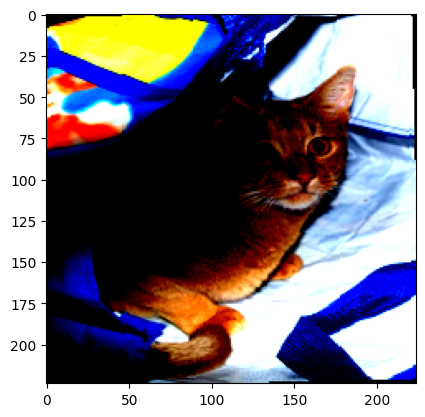

In [27]:
import matplotlib.pyplot as plt
plt.imshow(train_dataset[0][0].permute(1, 2, 0));

# Create validation set

In [28]:
test_size = int(0.8 * len(val_test_dataset))
val_size = len(val_test_dataset) - test_size
test_size, val_size

(2935, 734)

In [30]:
test_dataset, val_dataset = torch.utils.data.random_split(val_test_dataset, [test_size, val_size])

# transformations for each test

In [31]:
# Here we override the transformation that was originally assigned to the test validation set
# Transformations don't get 'trigggered' until we call __getitem__ on elements of the dataset
val_dataset.transform = val_test_transforms
val_dataset.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [32]:
# calling an index on the dataset calls the __getitem__ method
val_dataset[0]

(Image([[[-0.6281, -1.0390, -1.0390,  ..., -0.7137, -0.7308, -0.5938],
         [-1.5870, -1.0733, -1.0390,  ..., -0.9192, -1.0219, -0.4397],
         [-1.7240, -1.0733, -0.9534,  ..., -0.5767, -0.4226, -0.6109],
         ...,
         [ 0.6221,  0.5878,  0.4508,  ...,  1.2385,  1.2214,  1.2557],
         [ 0.5022,  0.3309,  0.5364,  ...,  1.3755,  1.2557,  1.2899],
         [ 0.9646,  0.5364,  0.5022,  ...,  1.5639,  1.4612,  1.4269]],
 
        [[-0.5476, -1.0203, -1.0028,  ..., -0.6877, -0.7402, -0.6176],
         [-1.5105, -1.0903, -1.0378,  ..., -0.8803, -1.0028, -0.4601],
         [-1.5980, -1.1253, -1.0378,  ..., -0.5826, -0.5126, -0.5826],
         ...,
         [ 0.7129,  0.6779,  0.5378,  ...,  1.3957,  1.3782,  1.4132],
         [ 0.5903,  0.4328,  0.6254,  ...,  1.5707,  1.3957,  1.4307],
         [ 1.0455,  0.6254,  0.5903,  ...,  1.7108,  1.6057,  1.5532]],
 
        [[-0.3230, -0.7587, -0.7413,  ..., -0.4101, -0.4450, -0.3055],
         [-1.2641, -0.8458, -0.8110,  ..., 

In [ ]:
val_dataset.__getitem__(0)

(<PIL.Image.Image image mode=RGB size=332x500>, 26)

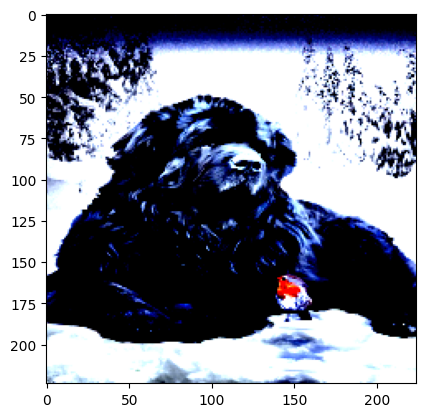

In [33]:
plt.imshow(val_dataset[0][0].permute(1, 2, 0))

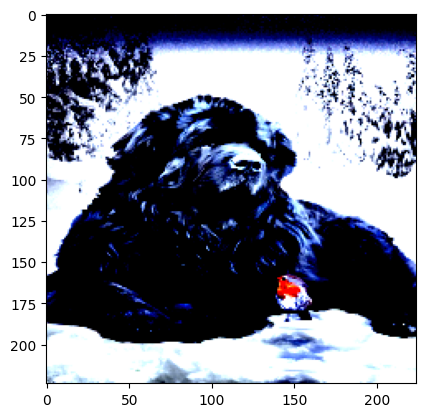

In [34]:
plt.imshow(val_dataset[0][0].permute(1, 2, 0))